In [ ]:
!pip install opencv-python torchvision scikit-learn matplotlib

In [ ]:
import sys
sys.path.append('/content')

Dataset loaded: (60000, 32, 32, 3)
Preprocessing images...
Training models...
Evaluating models...
SVM Accuracy: 0.383
KNN Accuracy: 0.240
Showing predictions...
Showing image enhancement...


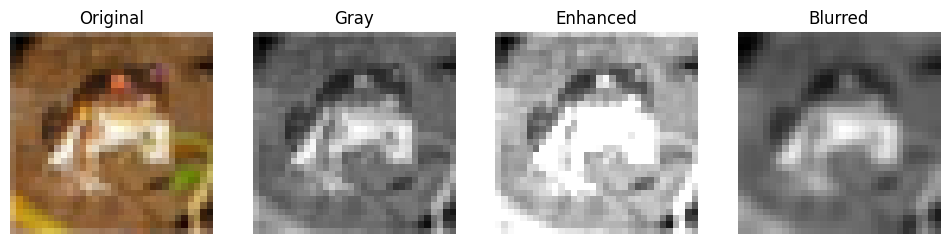

Done! ✅


In [11]:
# =========================
# INSTALL (Run this first in Colab)
# =========================
!pip install opencv-python torchvision scikit-learn matplotlib

# =========================
# IMPORTS
# =========================
import numpy as np
import cv2
import matplotlib.pyplot as plt

from torchvision import datasets
from sklearn.model_selection import train_test_split

from preprocess import preprocess, enhance_image
from train import train_models
from evaluate import evaluate_model
from visualize import show_predictions

# =========================
# LOAD CIFAR-10 DATASET
# =========================
print("Downloading CIFAR-10 dataset...")

train_data = datasets.CIFAR10(root='./data', train=True, download=True)
test_data = datasets.CIFAR10(root='./data', train=False, download=True)

X_train_raw = np.array([img for img, _ in train_data])
y_train = np.array([label for _, label in train_data])

X_test_raw = np.array([img for img, _ in test_data])
y_test = np.array([label for _, label in test_data])

# Merge dataset
X_all = np.concatenate([X_train_raw, X_test_raw])
y_all = np.concatenate([y_train, y_test])

print("Dataset loaded:", X_all.shape)

# =========================
# REDUCE DATA (FASTER EXECUTION)
# =========================
X_all = X_all[:10000]
y_all = y_all[:10000]

# =========================
# PREPROCESSING
# =========================
print("Preprocessing images...")
X = preprocess(X_all)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_all, test_size=0.2, random_state=42, stratify=y_all
)

# =========================
# TRAIN MODELS
# =========================
print("Training models...")
svm, knn = train_models(X_train, y_train)

# =========================
# EVALUATION
# =========================
print("Evaluating models...")
evaluate_model(svm, X_test, y_test, "SVM")
evaluate_model(knn, X_test, y_test, "KNN")

# =========================
# PREDICTION VISUALIZATION
# =========================
print("Showing predictions...")
show_predictions(svm, X_test_raw, X_test, y_test)

# =========================
# IMAGE ENHANCEMENT (FULL REQUIREMENT)
# =========================
print("Showing image enhancement...")

original = X_train_raw[0]
gray, enhanced, blurred = enhance_image(original)

plt.figure(figsize=(12,4))

plt.subplot(1,4,1)
plt.imshow(original)
plt.title("Original")
plt.axis('off')

plt.subplot(1,4,2)
plt.imshow(gray, cmap='gray')
plt.title("Gray")
plt.axis('off')

plt.subplot(1,4,3)
plt.imshow(enhanced, cmap='gray')
plt.title("Enhanced")
plt.axis('off')

plt.subplot(1,4,4)
plt.imshow(blurred, cmap='gray')
plt.title("Blurred")
plt.axis('off')

plt.show()

print("Done! ✅")